# Figuras principais (artigo)

Rode ablações (`5_run_*`) antes. Edite **`CFG`** / **`COHORT`** e a célula **Run**.

| Figura / artefacto | Função |
|--------|--------|
| Consolidar protocolos → `all_protocols_summary.csv` | célula **Consolidação** (1 cohort) |
| **Protocolos primary** → Clinical / Fusion / Wide / T1 / Leaky | célula após consolidação |
| **Multi-cohort** → `cohort_results.csv` + Δ wide−t1 | célula **Comparação cohorts** |
| Heatmap modalidade×modelo (patient-level AUC ± boot SD) | `plot_heatmap` |
| abs vs t1_only (longitudinal) | `plot_paired` |
| ROC (modelos + faixa ±SD + patient-level AUC ± boot SD) | `plot_roc_models` |
| Matriz de confusão (folds concatenados) | `plot_cm` |
| Tabela métricas — top-N por task×protocolo×ComBat | `build_results_top_table` |
| Tabela estabilidade (5 modalidades) | `build_stability_table` |
| Estabilidade L1 (1 modalidade, opcional) | `plot_stability` |

In [8]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

_MOD = Path.cwd() / "modules"
if str(_MOD) not in sys.path:
    sys.path.insert(0, str(_MOD))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

import importlib
import ablation_analysis

#importlib.reload(ablation_analysis)  # kernel pode ter módulo pré-edit
from ablation_analysis import (
    TIME_ORDER,
    anatomical_key,
    feature_freq_table_grouped,
    filter_ablation_config,
    filter_temporally_stable,
    parse_feature,
    plot_feature_stability_grouped,
    pooled_auc,
    pooled_predictions,
    patient_mean_auc,
    patient_mean_predictions,
    prepare_ablation_df,
    short_anatomical_key,
    summary_with_pooled,
)

# ── editar aqui ──────────────────────────────────────────────
COHORT = "36m_6m"  # deep-dive 1 cohort → csvs/cohorts/{COHORT}/
BASE = Path("csvs/cohorts") / COHORT
SAVE_FIGS = False
ARTIGO_DIR = Path("artigo")
FIG_DIR = ARTIGO_DIR / "figures"
TABLE_DIR = ARTIGO_DIR / "tables"
SUMMARY_PATH = BASE / "all_protocols_summary.csv"

# comparação entre populações (célula Comparação cohorts)
COHORTS_DIR = Path("csvs/cohorts")
COMPARE_DIR = Path("csvs/cohort_comparison")
COHORTS_COMPARE = [
    "36m_6m", "36m_9m", "36m_12m",
    "48m_6m", "48m_9m", "48m_12m",
]
# só gera CSVs para cohorts que já têm ablation_results/
COHORTS_COMPARE = [
    c for c in COHORTS_COMPARE
    if (COHORTS_DIR / c / "ablation_results").is_dir()
]

# protocolos na tabela-resumo do artigo vs suplemento
RESULTS_MAIN_PROTOCOLS = ("abs", "t1_only")
RESULTS_SUPP_PROTOCOLS = ("abs", "t1_only", "global", "clinica", "clinica+img", "clinica+img_t1")
RESULTS_TOP_N = 3  # melhores configs por (task, protocolo, ComBat)
RESULTS_TOP_GROUP = ("task", "protocol", "with_combat")

MOD_ORDER = ["vol", "shape", "texture", "disp", "all"]
MODEL_ORDER = ["svm", "rf", "elasticnet"]
ROC_COLORS = {"svm": "#4477AA", "rf": "#EE6677", "elasticnet": "#228833"}
N_BOOT_AUC = 2000  # bootstrap SD da patient-level AUC (subject-averaged OOF; mesmo estimador heatmap/ROC)
STAB_MIN_PCT = 70           # incidência mínima por tempo (%, igual l1_stable)
STAB_MIN_TIMEPOINTS = 0     # 0 = só frequência (Meinshausen-like); 2 = ≥2 tempos

MOD_LABELS = {
    "vol": "Volume",
    "shape": "Shape",
    "texture": "Texture",
    "disp": "DVF",
    "all": "All",
}
MODEL_LABELS = {
    "svm": "SVM",
    "rf": "RF",
    "elasticnet": "Elastic-Net",
}

PROTOCOL_ROOTS = {
    "abs": BASE / "ablation_results",
    "t1_only": BASE / "ablation_results_t1_only",
    "global": BASE / "ablation_results_leaky",  # wide leaky (inflate ""); t1_only_global se existir
}


@dataclass(frozen=True)
class CFG:
    selection_mode: str = "l1_stable"
    with_combat: bool = False
    task_primary: str = "smci_pmci"
    task_sanity: str = "cn_ad"
    model_primary: str = "svm"
    modality_primary: str = "vol"
    model_sanity: str = "svm"
    modality_sanity: str = "vol"


CFG = CFG()
TASK_LABELS = {"cn_ad": "CN × AD", "smci_pmci": "sMCI × pMCI"}
CM_LABELS = {
    "cn_ad": ("CN", "AD"),
    "smci_pmci": ("sMCI", "pMCI"),
}


def _csv(mod_dir: Path, stem: str, sel: str) -> Path:
    for name in (f"{stem}_{sel}.csv", f"{stem}.csv"):
        p = mod_dir / name
        if p.is_file():
            return p
    raise FileNotFoundError(f"{stem} ausente em {mod_dir}")


def load_summary(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    root = PROTOCOL_ROOTS[protocol]
    frames = []
    for mod in MOD_ORDER:
        d = root / mod
        if not d.is_dir():
            continue
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_summary", sel)))
        except FileNotFoundError:
            pass
    if not frames:
        raise FileNotFoundError(f"sem summary em {root}")
    return pd.concat(frames, ignore_index=True)


def load_ablation(protocol: str, sel: str = CFG.selection_mode) -> pd.DataFrame:
    if protocol not in PROTOCOL_ROOTS:
        raise KeyError(f"protocolo desconhecido: {protocol!r}. Known={list(PROTOCOL_ROOTS)}")
    root = PROTOCOL_ROOTS[protocol]
    if not root.is_dir():
        raise FileNotFoundError(f"pasta protocolo {protocol!r} inexistente: {root}")
    frames = []
    for mod in MOD_ORDER:
        d = root / mod
        if not d.is_dir():
            continue
        try:
            frames.append(pd.read_csv(_csv(d, "ablation_results_all", sel)))
        except FileNotFoundError:
            pass
    # sanity CN×AD (pasta fora de MOD_ORDER)
    if protocol == "abs":
        sanity_dir = root / "vol_cn_ad"
        if sanity_dir.is_dir():
            try:
                frames.append(pd.read_csv(_csv(sanity_dir, "ablation_results_all", sel)))
            except FileNotFoundError:
                pass
    if not frames:
        raise FileNotFoundError(
            f"sem ablation_results_all em {root} (protocol={protocol!r}). "
            f"Mods presentes: {[p.name for p in root.iterdir() if p.is_dir()] if root.is_dir() else []}"
        )
    return prepare_ablation_df(pd.concat(frames, ignore_index=True))


def filter_cfg(df: pd.DataFrame, *, task: str, combat: bool | None = None) -> pd.DataFrame:
    out = df[df["selection_mode"].astype(str) == CFG.selection_mode].copy()
    combat = CFG.with_combat if combat is None else combat
    out = out[out["with_combat"] == combat]
    out = out[out["task"].astype(str) == task]
    return out


def save_fig(fig, name: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Salvo:", path)
    plt.show()
    plt.close(fig)


ablation_abs = load_ablation("abs")
summary_abs = summary_with_pooled(ablation_abs)
summary_all = pd.read_csv(SUMMARY_PATH) if SUMMARY_PATH.is_file() else pd.DataFrame()

# sanity CN×AD: pasta vol_cn_ad (fora de MOD_ORDER)
_SANITY_CSV = BASE / "ablation_results" / "vol_cn_ad" / "ablation_results_all.csv"
if _SANITY_CSV.is_file():
    ablation_sanity = prepare_ablation_df(pd.read_csv(_SANITY_CSV))
    if "selection_mode" in ablation_sanity.columns:
        ablation_sanity = ablation_sanity.loc[
            ablation_sanity["selection_mode"].astype(str) == CFG.selection_mode
        ].copy()
    print(f"sanity cn_ad: {_SANITY_CSV.relative_to(BASE)} | {len(ablation_sanity)} linhas")
else:
    ablation_sanity = pd.DataFrame()
    print(f"MISS sanity: {_SANITY_CSV}")

print(f"Saída → {ARTIGO_DIR} | {CFG.selection_mode} | ComBat={CFG.with_combat}")
print(f"summary_abs recomputado com patient-level AUC (auc_patient_mean) | {len(summary_abs)} configs")
if not summary_all.empty:
    print(f"Summary: {len(summary_all)} linhas em {SUMMARY_PATH.name}")

Saída → artigo | l1_stable | ComBat=False
summary_abs recomputado com patient-level AUC (auc_patient_mean) | 30 configs
Summary: 46 linhas em all_protocols_summary.csv


In [9]:
CONFIG_COLS = ["task", "modality", "model_key", "with_combat", "selection_mode"]
CONSOLIDATION_PROTOCOL_ROOTS = {
    "abs": BASE / "ablation_results",
    "t1_only": BASE / "ablation_results_t1_only",
    "deltas": BASE / "ablation_results_deltas",
    "deltas_only": BASE / "ablation_results_deltas_only",
    "deltas_rel": BASE / "ablation_results_deltas_rel",
    "global": BASE / "ablation_results_leaky",
    "t1_only_global": BASE / "ablation_results_leaky_t1_only",
    "clinica": BASE / "ablation_results_clinic",
    "clinica+img": BASE / "ablation_results_clinic_img",
    "clinica+img_t1": BASE / "ablation_results_clinic_img_t1_only",
}


def _summary_files(root: Path) -> list[Path]:
    # 1º nível; ignora backup / sanity misturados na pasta abs
    def _ok(p: Path) -> bool:
        blob = f"{p.parent.name}/{p.stem}".lower()
        return "backup" not in blob and "_cn_ad" not in blob

    files = [f for f in root.glob("*/ablation_summary.csv") if _ok(f)]
    files += [
        f for f in root.glob("*summary*.csv")
        if not f.name.startswith("all_") and _ok(f)
    ]
    return files


def build_all_protocols_summary() -> pd.DataFrame:
    frames = []
    for proto, root in CONSOLIDATION_PROTOCOL_ROOTS.items():
        if not root.is_dir():
            continue
        for f in _summary_files(root):
            df = pd.read_csv(f)
            df.insert(0, "protocol", proto)
            df["source_file"] = str(f.relative_to(BASE))
            df["source_mtime"] = pd.Timestamp(f.stat().st_mtime, unit="s")
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    master = pd.concat(frames, ignore_index=True)
    keys = ["protocol"] + [c for c in CONFIG_COLS if c in master.columns]
    master = master.sort_values("source_mtime").drop_duplicates(keys, keep="last")
    front = ["protocol", *CONFIG_COLS, "auc_patient_mean", "auc_pooled", "auc_mean", "auc_std", "n_features_mean"]
    front = [c for c in front if c in master.columns]
    master = master[front + [c for c in master.columns if c not in front]]
    rank_col = "auc_patient_mean" if "auc_patient_mean" in master.columns else "auc_pooled"
    return master.sort_values([rank_col, "protocol"], ascending=[False, True]).reset_index(drop=True)
    # return master.sort_values(["protocol", rank_col], ascending=[True, False]).reset_index(drop=True)


summary_all = build_all_protocols_summary()
if summary_all.empty:
    print(f"{SUMMARY_PATH.name} vazio — rode ablations antes")
else:
    summary_all.to_csv(SUMMARY_PATH, index=False)
    print(f"Salvo: {SUMMARY_PATH} | {len(summary_all)} linhas")
    print(summary_all.groupby("protocol").size().rename("linhas").to_string())
    show_cols = ["protocol"] + [c for c in CONFIG_COLS if c in summary_all.columns]
    show_cols += [c for c in ("auc_patient_mean", "auc_pooled") if c in summary_all.columns]
    display(summary_all[show_cols].head(100))

Salvo: csvs/cohorts/36m_6m/all_protocols_summary.csv | 46 linhas
protocol
abs            31
clinica         1
clinica+img     1
deltas          1
global          1
t1_only        11


,protocol,task,modality,model_key,with_combat,selection_mode,auc_patient_mean,auc_pooled
0,clinica+img,smci_pmci,vol,svm,False,l1_stable,0.866158,0.850006
1,clinica,smci_pmci,clinical,svm,False,none,0.855120,0.848203
2,abs,cn_ad,vol,svm,False,l1_stable,0.823925,0.813104
3,abs,smci_pmci,texture,elasticnet,True,l1_stable,0.775672,0.749528
4,t1_only,smci_pmci,shape,svm,False,l1_stable,0.770007,0.762423
5,abs,smci_pmci,shape,svm,False,l1_stable,0.767466,0.758574
6,abs,smci_pmci,texture,rf,True,l1_stable,0.766957,0.756679
7,abs,smci_pmci,texture,svm,True,l1_stable,0.766158,0.753395
8,abs,smci_pmci,texture,rf,False,l1_stable,0.766158,0.759871
9,abs,smci_pmci,all,elasticnet,True,l1_stable,0.766086,0.741675


## Protocolos no primary (`36m_6m`)

Barras: **Clinical / Fusion / Wide / T1 / Leaky** — patient-level AUC, `vol` (ou `clinical`), svm, no ComBat.  
Dados de `summary_all` (célula consolidação). Sem novo treino.

In [ ]:
# wide vs t1 vs clinic vs fusion vs leaky — primary cohort (COHORT / CFG)
PROTOCOL_COMPARE = (
    ("clinica", "clinical", "Clinical"),
    ("clinica+img", "vol", "Fusion"),
    ("abs", "vol", "Wide"),
    ("t1_only", "vol", "T1"),
    ("global", "vol", "Leaky"),
)
BACKUP_RE = r"backup|_cn_ad"

rows = []
if summary_all.empty:
    print("summary_all vazio — rode consolidação antes")
else:
    s = summary_all.copy()
    if "with_combat" in s.columns:
        s["with_combat"] = s["with_combat"].map(
            lambda x: str(x).strip().lower() in ("1", "true", "yes")
        )
    if "source_file" in s.columns:
        s = s.loc[
            ~s["source_file"].astype(str).str.contains(BACKUP_RE, regex=True, na=False)
        ]

    for proto, mod, label in PROTOCOL_COMPARE:
        hit = s.query(
            "protocol == @proto and task == @CFG.task_primary "
            "and modality == @mod and model_key == @CFG.model_primary "
            "and with_combat == False"
        )
        if hit.empty:
            print(f"MISS: {label} ({proto}/{mod})")
            continue
        r = hit.iloc[0]
        rows.append({
            "label": label,
            "protocol": proto,
            "modality": mod,
            "auc_patient_mean": float(r["auc_patient_mean"]),
            "auc_std": float(r["auc_std"]) if pd.notna(r.get("auc_std")) else float("nan"),
            "auc_pooled": float(r["auc_pooled"]) if "auc_pooled" in r and pd.notna(r["auc_pooled"]) else float("nan"),
            "n_features_mean": r.get("n_features_mean"),
            "source_file": r.get("source_file", ""),
        })

    proto_cmp = pd.DataFrame(rows)
    if proto_cmp.empty:
        print("Nenhuma linha protocol compare — falta clinic/fusion/leaky/wide/t1?")
    else:
        # ordem fixa
        order = [lab for _, _, lab in PROTOCOL_COMPARE if lab in set(proto_cmp["label"])]
        proto_cmp["label"] = pd.Categorical(proto_cmp["label"], categories=order, ordered=True)
        proto_cmp = proto_cmp.sort_values("label").reset_index(drop=True)

        print(f"Protocolos primary | {COHORT} | {CFG.task_primary} | {CFG.model_primary} | no ComBat")
        display(proto_cmp.drop(columns=["source_file"], errors="ignore").round(4))

        out_csv = BASE / "protocol_compare_primary.csv"
        proto_cmp.to_csv(out_csv, index=False)
        print(f"CSV: {out_csv}")

        colors = {
            "Clinical": "#228833",
            "Fusion": "#AA3377",
            "Wide": "#4477AA",
            "T1": "#EE6677",
            "Leaky": "#CCBB44",
        }
        fig, ax = plt.subplots(figsize=(7.5, 4))
        x = np.arange(len(proto_cmp))
        bar_c = [colors.get(lab, "#888888") for lab in proto_cmp["label"].astype(str)]
        ax.bar(
            x,
            proto_cmp["auc_patient_mean"],
            yerr=proto_cmp["auc_std"],
            capsize=4,
            color=bar_c,
            ecolor="#333333",
            width=0.7,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(proto_cmp["label"].astype(str))
        ax.set_ylabel("Patient-level AUC")
        ax.set_ylim(0.5, 1.0)
        ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
        ax.set_title(
            f"Primary protocols | {COHORT} | vol/clinical | {CFG.model_primary} | no ComBat"
        )
        for i, v in enumerate(proto_cmp["auc_patient_mean"]):
            ax.text(i, min(0.99, v + 0.025), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        save_fig(fig, "protocol_compare_primary")
        plt.show()


In [ ]:
def _patient_mean_cell(df: pd.DataFrame, *, task: str, modality: str, model: str) -> tuple[float, float]:
    """Patient-level AUC (subject-averaged OOF) + bootstrap SD (mesmo estimador ROC)."""
    sub = filter_ablation_config(
        df, task=task, modality=modality, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    y, s = patient_mean_predictions(sub)
    auc = float(roc_auc_score(y, s))
    sd = bootstrap_auc_std(y, s)
    return auc, sd


def plot_heatmap(df, task: str, *, title: str, fname: str, vmin=0.5, vmax=1.0):
    """Heatmap patient-level AUC ± bootstrap SD (ablation raw, não summary)."""
    sub = filter_cfg(df, task=task)
    mods = [m for m in MOD_ORDER if m in sub["modality"].astype(str).unique()]
    models = [m for m in MODEL_ORDER if m in sub["model_key"].astype(str).unique()]
    auc_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    sd_w = pd.DataFrame(index=models, columns=mods, dtype=float)
    for model in models:
        for mod in mods:
            try:
                auc, sd = _patient_mean_cell(df, task=task, modality=mod, model=model)
            except (ValueError, KeyError) as e:
                print(f"heatmap skip {task}/{mod}/{model}: {e}")
                continue
            auc_w.loc[model, mod] = auc
            sd_w.loc[model, mod] = sd
    if auc_w.size == 0 or not mods or not models:
        print(f"heatmap skip {task}: sem dados (mods={mods}, models={models})")
        return
    auc_w = auc_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    sd_w = sd_w.rename(index=MODEL_LABELS, columns=MOD_LABELS)
    annot = np.asarray(
        [
            ["" if pd.isna(p) else f"{p:.3f}±{s:.2f}" for p, s in zip(auc_w.iloc[i], sd_w.iloc[i])]
            for i in range(len(auc_w))
        ],
        dtype=object,
    ).reshape(auc_w.shape)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.heatmap(auc_w.astype(float), annot=annot, fmt="", cmap="YlOrRd",
                vmin=vmin, vmax=vmax, ax=ax, cbar_kws={"label": "Patient-level AUC"})
    ax.set_xlabel("Modality")
    ax.set_ylabel("Classifier")
    ax.set_title(title)
    plt.tight_layout()
    save_fig(fig, fname)


def plot_paired(protocols: tuple[str, ...], task: str, model: str, *, title: str, fname: str, labels: dict | None = None):
    """Barras pareadas por modalidade (patient-level AUC)."""
    labels = labels or {p: p for p in protocols}
    rows = []
    for proto in protocols:
        try:
            raw = load_ablation(proto)
        except (FileNotFoundError, KeyError, ValueError) as exc:
            print(f"plot_paired: skip protocol={proto!r} ({exc})")
            continue
        for mod in MOD_ORDER:
            try:
                auc, _ = _patient_mean_cell(raw, task=task, modality=mod, model=model)
            except (ValueError, KeyError, FileNotFoundError):
                continue
            rows.append({"modality": mod, "protocol": proto, "auc": auc})
    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        print(f"plot_paired vazio: {protocols} | {task} | {model}")
        return
    wide = plot_df.pivot(index="modality", columns="protocol", values="auc").reindex(
        [m for m in MOD_ORDER if m in plot_df["modality"].unique()]
    )
    x = np.arange(len(wide))
    w = 0.8 / len(protocols)
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, proto in enumerate(protocols):
        if proto not in wide.columns:
            continue
        ax.bar(x + (i - (len(protocols) - 1) / 2) * w, wide[proto], w, label=labels.get(proto, proto))
    ax.set_xticks(x, wide.index)
    y_max = min(1.0, max(0.8, np.ceil((np.nanmax(wide.to_numpy()) + 0.08) * 10) / 10))
    ax.set_ylim(0.0, y_max)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.set_ylabel("Patient-level AUC")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    save_fig(fig, fname)


def _interp_tpr(fpr, tpr, grid: np.ndarray) -> np.ndarray:
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)


def roc_fold_bands(sub: pd.DataFrame, fpr_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """TPR médio ± SD entre avaliações externas (fold × repeat)."""
    tpr_rows: list[np.ndarray] = []
    for _, row in sub.iterrows():
        y = np.asarray(json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(_interp_tpr(fpr, tpr, fpr_grid))
    if not tpr_rows:
        raise ValueError("Nenhum fold com duas classes")
    stack = np.vstack(tpr_rows)
    return stack.mean(axis=0), stack.std(axis=0, ddof=0)


def bootstrap_auc_std(y, scores, *, n_boot: int = N_BOOT_AUC, seed: int = 0) -> float:
    """SD da AUC (patient-level / subject-averaged OOF ou pooled) por bootstrap nas predições agregadas."""
    y = np.asarray(y, dtype=int)
    scores = np.asarray(scores, dtype=float)
    rng = np.random.default_rng(seed)
    aucs: list[float] = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        yb, sb = y[idx], scores[idx]
        if len(np.unique(yb)) < 2:
            continue
        aucs.append(float(roc_auc_score(yb, sb)))
    if not aucs:
        return float("nan")
    return float(np.std(aucs, ddof=0))


def plot_roc_models(
    df,
    task: str,
    mod: str,
    *,
    title: str,
    fname: str,
    models: list[str] | None = None,
    score_agg: str = "patient_mean",
):
    """ROC: faixa = ±SD TPR entre folds; legenda = patient-level AUC ± bootstrap SD."""
    agg_fn = patient_mean_predictions if score_agg == "patient_mean" else pooled_predictions
    models = models or MODEL_ORDER
    fpr_grid = np.linspace(0, 1, 101)
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for i, model in enumerate(models):
        try:
            sub = filter_ablation_config(
                df, task=task, modality=mod, model_key=model,
                with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
            )
        except ValueError as e:
            print(f"ROC skip {model}: {e}")
            continue
        tpr_m, tpr_s = roc_fold_bands(sub, fpr_grid)
        y, scores = agg_fn(sub)
        auc = float(roc_auc_score(y, scores))
        sd = bootstrap_auc_std(y, scores, seed=100 + i)
        color = ROC_COLORS.get(model, f"C{i}")
        ax.fill_between(
            fpr_grid,
            np.clip(tpr_m - tpr_s, 0, 1),
            np.clip(tpr_m + tpr_s, 0, 1),
            color=color, alpha=0.22, linewidth=0,
        )
        model_label = MODEL_LABELS.get(model, model)
        ax.plot(fpr_grid, tpr_m, color=color, lw=2, label=f"{model_label}  {auc:.3f}±{sd:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.text(
        0.03, 0.97, TASK_LABELS.get(task, task), transform=ax.transAxes,
        va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="0.85", edgecolor="0.6"),
    )
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=10, title="Patient-level AUC ± SD")
    ax.set_aspect("equal")
    plt.tight_layout()
    save_fig(fig, fname)


def plot_cm(df, task: str, mod: str, model: str, *, title: str, fname: str):
    """AUTOLOAD_CN_AD_v2: se cn_ad faltar no DF, lê vol_cn_ad do COHORT."""
    df = df.copy() if df is not None and not getattr(df, "empty", True) else pd.DataFrame()
    need = (
        task == CFG.task_sanity
        or str(task) == "cn_ad"
    ) and (
        df.empty or "task" not in df.columns or "cn_ad" not in set(df["task"].astype(str))
    )
    if need:
        sanity_csv = BASE / "ablation_results" / "vol_cn_ad" / "ablation_results_all.csv"
        if not sanity_csv.is_file():
            raise FileNotFoundError(
                f"plot_cm: sem {sanity_csv} para task={task!r}. "
                "Corre ablação sanity ou re-executa imports."
            )
        df = prepare_ablation_df(pd.read_csv(sanity_csv))
        if "selection_mode" in df.columns:
            df = df.loc[df["selection_mode"].astype(str) == CFG.selection_mode].copy()
        print(f"plot_cm AUTOLOAD_CN_AD_v2 ← {sanity_csv.relative_to(BASE)} | n={len(df)}")
    sub = filter_ablation_config(
        df, task=task, modality=mod, model_key=model,
        with_combat=CFG.with_combat, selection_mode=CFG.selection_mode,
    )
    x = np.arange(len(wide))
    w = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w / 2, wide["no ComBat"], w, label="No Harmonization")
    ax.bar(x + w / 2, wide["ComBat"], w, label="With Harmonization")
    ax.set_xticks(x, wide.index)
    y_max = min(1.0, max(0.8, np.ceil((np.nanmax(wide.to_numpy()) + 0.08) * 10) / 10))
    ax.set_ylim(0.0, y_max)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.set_ylabel("Patient-level AUC" if auc_col == "auc_patient_mean" else "AUC pooled")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    save_fig(fig, fname)

In [ ]:
# ── Run ──────────────────────────────────────────────────────
# Garante AUTOLOAD cn_ad mesmo com kernel/células desatualizadas:
import importlib
import ablation_analysis as _abl_mod
importlib.reload(_abl_mod)
from ablation_analysis import (
    filter_ablation_config,
    prepare_ablation_df,
    summary_with_pooled,
)

# cn_ad está em ablation_abs via vol_cn_ad (load_ablation) e também em ablation_sanity.
_tag = f"{CFG.selection_mode}_" + ("combat" if CFG.with_combat else "nocombat")
_tasks_abs = sorted(ablation_abs["task"].astype(str).unique())
print(
    "mods em ablation_abs:",
    sorted(ablation_abs["modality"].astype(str).unique()),
    "| tasks=",
    _tasks_abs,
    "| combat CFG=",
    CFG.with_combat,
)
if "cn_ad" not in _tasks_abs:
    print("AVISO: cn_ad ausente em ablation_abs — re-executa célula imports")

# 1. Heatmaps
plot_heatmap(
    ablation_abs, CFG.task_primary,
    title="",
    fname=f"heatmap_{CFG.task_primary}",
)
if "cn_ad" in _tasks_abs:
    plot_heatmap(
        ablation_abs, CFG.task_sanity,
        title="",
        fname=f"heatmap_{CFG.task_sanity}",
    )

# 2. Longitudinal: abs vs t1_only (opcional)
# plot_paired(
#     ("abs", "t1_only"), CFG.task_primary, CFG.model_primary,
#     labels={"abs": "Longitudinal", "t1_only": "Baseline"},
#     title="",
#     fname="abs_t1only",
# )

# 3. ROC patient-level
plot_roc_models(
    ablation_abs, CFG.task_primary, CFG.modality_primary,
    title="",
    fname=f"roc_{CFG.task_primary}",
    score_agg="patient_mean",
)
if "cn_ad" in _tasks_abs:
    plot_roc_models(
        ablation_abs, CFG.task_sanity, CFG.modality_sanity,
        title="",
        fname=f"roc_{CFG.task_sanity}",
        score_agg="patient_mean",
    )

# 4. Matriz de confusão
plot_cm(
    ablation_abs, CFG.task_primary, CFG.modality_primary, CFG.model_primary,
    title="",
    fname=f"cm_{CFG.task_primary}",
)
if "cn_ad" in _tasks_abs:
    plot_cm(
        ablation_abs, CFG.task_sanity, CFG.modality_sanity, CFG.model_sanity,
        title="",
        fname=f"cm_{CFG.task_sanity}",
    )
else:
    print("skip cm cn_ad — task ausente no DF")

# 6. Tabelas de métricas
if not summary_all.empty:
    results_main = build_results_top_table(
        summary_all,
        tasks=("smci_pmci",),
        protocols=RESULTS_MAIN_PROTOCOLS,
        selection_mode=CFG.selection_mode,
        n_top=RESULTS_TOP_N,
    )

    drop_cols = [
        "rank",
        "task_label",
        "combat",
        "selection_mode",
        "n_outer_evals",
        "auc",
        "mcc",
        "auc_pr",
    ]
    results_main = results_main.drop(columns=[c for c in drop_cols if c in results_main.columns])

    print(
        f"Tabela main (top-{RESULTS_TOP_N} por {RESULTS_TOP_GROUP}) | "
        f"{CFG.selection_mode} | {len(results_main)} linhas"
    )
    display(results_main)
    save_table(results_main, "main_results")
else:
    print("all_protocols_summary.csv ausente — rode a célula de consolidação acima")

# 5. Estabilidade
stab_tbl = build_stability_table(ablation_abs, CFG.task_primary, CFG.model_primary)
print(
    f"Tabela estabilidade | {TASK_LABELS[CFG.task_primary]} | {CFG.model_primary} "
    f"| ≥{STAB_MIN_PCT}% em ≥{STAB_MIN_TIMEPOINTS} tempos"
)
display(stab_tbl)
if not stab_tbl.empty:
    save_stability_table(stab_tbl, "stability")

# ── Suplemento (opcional) ──────
# plot_paired(
#     ("abs", "global"), CFG.task_primary, CFG.model_primary,
#     labels={"abs": "Leak-free", "global": "Leaky"},
#     title="",
#     fname="abs_global",
# )
# plot_combat(
#     summary_abs, CFG.task_primary, CFG.model_primary,
#     title="",
#     fname="combat",
# )

# === SUPLEMENTO_CANCELADO ===
# NÃO descomentar plot_paired/plot_combat no primary paper.
# Leaky já está na figura protocol_compare_primary (barra Leaky).


## Comparação multi-cohort

Gera CSVs em `csvs/cohort_comparison/`:

1. **`cohort_results.csv`** — configs × métricas + `auc_patient_mean`± boot SD.
2. **`cohort_features_long.csv`** — atributos estáveis por `anatomical_key`.
3. **`wide_vs_t1_by_modality.csv`** — wide vs t1 + `delta_wide_t1` (ignora `*_backup` / `_cn_ad`).

Figuras: barras wide vs t1 por modalidade × cohort; heatmap Δ; Δ vs `t_imagens` (facet `t_janela`).

Requer ablação por cohort. Edite `COHORTS_COMPARE` na 1ª célula.

Carrega cache: csvs/cohort_comparison/cohort_results.csv (REBUILD_COMPARE=False)
Usando 93 linhas results (sem backup/_cn_ad)
Features: 572 linhas

=== Tabela: wide vs t1_only (patient-level AUC) ===


,cohort,t_janela,t_imagens,n_smci,n_pmci,modality,auc_wide,sd_wide,auc_t1,sd_t1,delta_wide_t1
0,36m_6m,36,6,153,90,vol,0.7145,0.0338,0.7150,0.0336,-0.0004
1,36m_6m,36,6,153,90,shape,0.7675,0.0308,0.7700,0.0310,-0.0025
2,36m_6m,36,6,153,90,texture,0.7573,0.0306,0.7129,0.0334,0.0444
3,36m_6m,36,6,153,90,disp,0.5582,0.0383,0.5611,0.0384,-0.0028
4,36m_6m,36,6,153,90,all,0.7594,0.0309,0.7230,0.0329,0.0364
5,36m_9m,36,9,137,41,vol,0.6970,0.0455,0.6762,0.0455,0.0208
6,36m_9m,36,9,137,41,shape,0.7365,0.0427,0.7185,0.0427,0.0180
7,36m_9m,36,9,137,41,texture,0.7817,0.0363,0.7290,0.0416,0.0527
8,36m_9m,36,9,137,41,disp,0.6393,0.0481,0.6017,0.0483,0.0376
9,36m_9m,36,9,137,41,all,0.7963,0.0366,0.7484,0.0397,0.0479



AUC wide:


modality,vol,shape,texture,disp,all
cohort,,,,,
36m_6m,0.715,0.767,0.757,0.558,0.759
36m_9m,0.697,0.737,0.782,0.639,0.796
36m_12m,0.638,0.758,0.729,0.327,0.729
48m_6m,0.719,0.778,0.736,0.555,0.735
48m_9m,0.656,0.743,0.753,0.585,0.764
48m_12m,0.683,0.770,0.707,0.573,0.707



AUC t1_only:


modality,vol,shape,texture,disp,all
cohort,,,,,
36m_6m,0.715,0.770,0.713,0.561,0.723
36m_9m,0.676,0.719,0.729,0.602,0.748
36m_12m,0.678,0.743,0.671,0.386,0.669
48m_6m,0.710,0.781,0.705,0.565,0.708
48m_9m,0.646,0.745,0.715,0.602,0.737
48m_12m,0.650,0.758,0.658,0.609,0.650



Δ (wide − t1):


modality,vol,shape,texture,disp,all
cohort,,,,,
36m_6m,-0.000,-0.003,0.044,-0.003,0.036
36m_9m,0.021,0.018,0.053,0.038,0.048
36m_12m,-0.040,0.015,0.058,-0.059,0.060
48m_6m,0.010,-0.003,0.030,-0.010,0.027
48m_9m,0.009,-0.002,0.038,-0.017,0.027
48m_12m,0.033,0.012,0.048,-0.036,0.057


CSV: csvs/cohort_comparison/wide_vs_t1_by_modality.csv


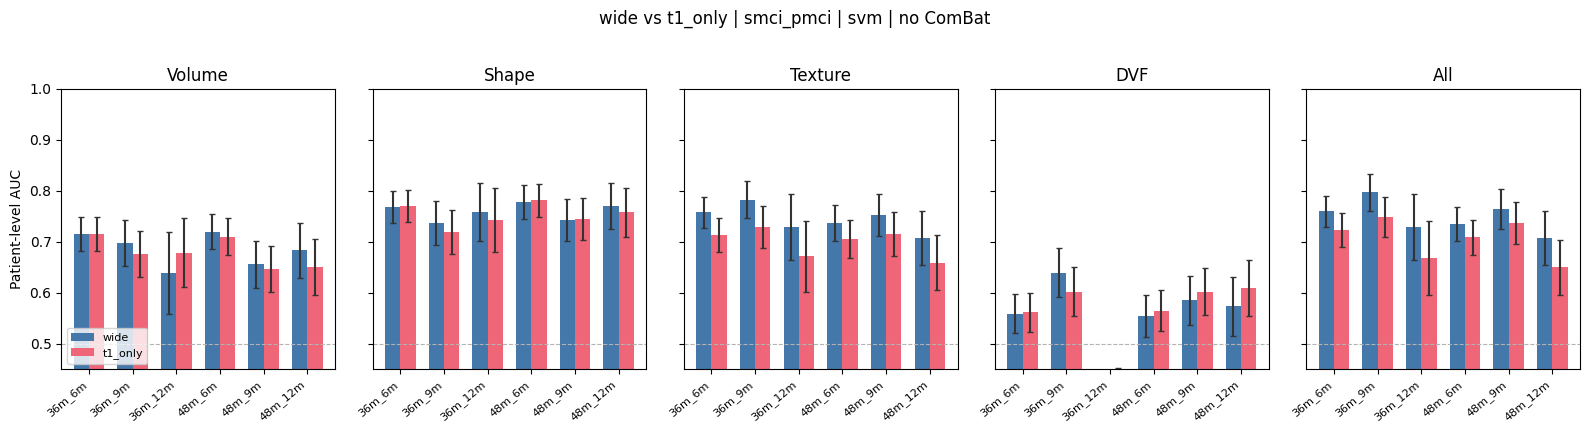

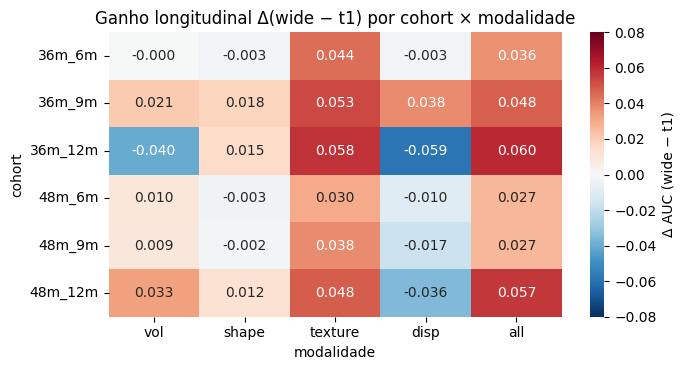

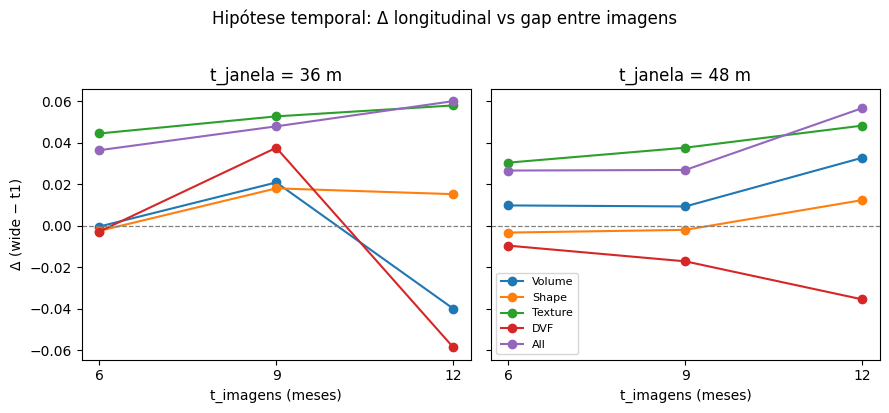


Primary paper (vol):


,cohort,n_smci,n_pmci,auc_wide,auc_t1,delta_wide_t1
0,36m_6m,153,90,0.7145,0.7150,-0.0004
5,36m_9m,137,41,0.6970,0.6762,0.0208
10,36m_12m,69,21,0.6384,0.6784,-0.0400
15,48m_6m,96,109,0.7194,0.7097,0.0097
20,48m_9m,90,60,0.6557,0.6465,0.0093
25,48m_12m,71,40,0.6827,0.6500,0.0327


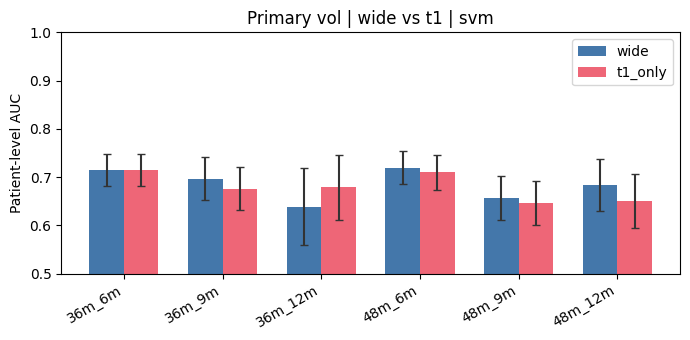


Atributos estáveis (pct≥70) no primary wide/vol: 38 linhas


,cohort,anatomical_key,feature_short,pct,pct_T1,pct_T2,pct_T3
28,36m_12m,hippocampus_L_csf_norm,L | csf_norm,100,100,100.0,100.0
29,36m_12m,hippocampus_L_gm_norm,L | gm_norm,100,100,100.0,100.0
30,36m_12m,hippocampus_R_csf_norm,R | csf_norm,100,100,100.0,100.0
31,36m_12m,hippocampus_R_gm_norm,R | gm_norm,100,100,100.0,100.0
32,36m_12m,hippocampus_L_wm_norm,L | wm_norm,72,56,72.0,72.0
267,36m_6m,hippocampus_L_csf_norm,L | csf_norm,100,100,100.0,100.0
268,36m_6m,hippocampus_L_gm_norm,L | gm_norm,100,100,100.0,100.0
269,36m_6m,hippocampus_R_csf_norm,R | csf_norm,100,100,100.0,100.0
270,36m_6m,hippocampus_R_gm_norm,R | gm_norm,100,100,100.0,100.0
271,36m_6m,hippocampus_L_wm_norm,L | wm_norm,100,92,100.0,96.0


In [12]:
import importlib
import cohort_compare

importlib.reload(cohort_compare)
from cohort_compare import save_cohort_comparison

BACKUP_RE = r"backup|_cn_ad"
COHORT_ORDER = [c for c in (
    "36m_6m", "36m_9m", "36m_12m", "48m_6m", "48m_9m", "48m_12m",
) if c in COHORTS_COMPARE]


def _drop_backup_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "source_file" not in df.columns:
        return df
    return df.loc[
        ~df["source_file"].astype(str).str.contains(BACKUP_RE, regex=True, na=False)
    ].copy()


REBUILD_COMPARE = False  # True = re-corre bootstrap (lento)

if not COHORTS_COMPARE:
    print("Nenhum cohort com ablation_results/ — rode 5_run_* antes.")
else:
    p_res = COMPARE_DIR / "cohort_results.csv"
    p_feat = COMPARE_DIR / "cohort_features_long.csv"
    if REBUILD_COMPARE or not p_res.is_file():
        print("Cohorts:", COHORTS_COMPARE)
        p_res, p_feat, cohort_results, cohort_features = save_cohort_comparison(
            COHORTS_COMPARE,
            COMPARE_DIR,
            cohorts_root=COHORTS_DIR,
            n_boot=N_BOOT_AUC,
        )
    else:
        print(f"Carrega cache: {p_res} (REBUILD_COMPARE=False)")
        cohort_results = pd.read_csv(p_res)
        cohort_features = pd.read_csv(p_feat) if p_feat.is_file() else pd.DataFrame()

    cohort_results = _drop_backup_rows(cohort_results)
    if not cohort_features.empty and "source_file" in cohort_features.columns:
        cohort_features = _drop_backup_rows(cohort_features)
    # CSV pode trazer with_combat como str
    if "with_combat" in cohort_results.columns:
        cohort_results["with_combat"] = cohort_results["with_combat"].map(
            lambda x: str(x).strip().lower() in ("1", "true", "yes")
        )
    print(f"Usando {len(cohort_results)} linhas results (sem backup/_cn_ad)")
    print(f"Features: {len(cohort_features)} linhas")

    # ── wide vs t1 por modality × cohort (svm, no ComBat, smci_pmci) ──
    base = cohort_results.query(
        "task == @CFG.task_primary and model_key == @CFG.model_primary "
        "and with_combat == False and protocol in ('abs', 't1_only')"
    ).copy()
    base["protocol"] = base["protocol"].replace({"abs": "wide"})
    # 1 linha por chave (se ainda houver duplicata)
    key = ["cohort", "protocol", "modality"]
    base = (
        base.sort_values(key)
        .drop_duplicates(subset=key, keep="first")
    )

    wide = base.query("protocol == 'wide'")[
        ["cohort", "t_janela", "t_imagens", "n_smci", "n_pmci", "modality",
         "auc_patient_mean", "auc_patient_std"]
    ].rename(columns={
        "auc_patient_mean": "auc_wide",
        "auc_patient_std": "sd_wide",
    })
    t1 = base.query("protocol == 't1_only'")[
        ["cohort", "modality", "auc_patient_mean", "auc_patient_std"]
    ].rename(columns={
        "auc_patient_mean": "auc_t1",
        "auc_patient_std": "sd_t1",
    })
    cmp = wide.merge(t1, on=["cohort", "modality"], how="inner")
    cmp["delta_wide_t1"] = cmp["auc_wide"] - cmp["auc_t1"]
    cmp["modality"] = pd.Categorical(cmp["modality"], categories=MOD_ORDER, ordered=True)
    cmp["cohort"] = pd.Categorical(cmp["cohort"], categories=COHORT_ORDER, ordered=True)
    cmp = cmp.sort_values(["cohort", "modality"]).reset_index(drop=True)

    print("\n=== Tabela: wide vs t1_only (patient-level AUC) ===")
    display(
        cmp[[
            "cohort", "t_janela", "t_imagens", "n_smci", "n_pmci", "modality",
            "auc_wide", "sd_wide", "auc_t1", "sd_t1", "delta_wide_t1",
        ]].round(4)
    )

    pivot_wide = cmp.pivot(index="cohort", columns="modality", values="auc_wide")
    pivot_t1 = cmp.pivot(index="cohort", columns="modality", values="auc_t1")
    pivot_delta = cmp.pivot(index="cohort", columns="modality", values="delta_wide_t1")
    for name, piv in (
        ("AUC wide", pivot_wide),
        ("AUC t1_only", pivot_t1),
        ("Δ (wide − t1)", pivot_delta),
    ):
        print(f"\n{name}:")
        display(piv.reindex(columns=[m for m in MOD_ORDER if m in piv.columns]).round(3))

    cmp_path = COMPARE_DIR / "wide_vs_t1_by_modality.csv"
    COMPARE_DIR.mkdir(parents=True, exist_ok=True)
    cmp.to_csv(cmp_path, index=False)
    print(f"CSV: {cmp_path}")

    # ── plot 1: barras agrupadas wide vs t1 por cohort (1 painel / modalidade) ──
    mods_plot = [m for m in MOD_ORDER if m in cmp["modality"].astype(str).unique()]
    n_mod = len(mods_plot)
    if n_mod and len(cmp):
        fig, axes = plt.subplots(
            1, n_mod, figsize=(3.2 * n_mod, 4.2), sharey=True, squeeze=False,
        )
        x = np.arange(len(COHORT_ORDER))
        w = 0.35
        for ax, mod in zip(axes[0], mods_plot):
            sub = cmp.loc[cmp["modality"] == mod].set_index("cohort").reindex(COHORT_ORDER)
            ax.bar(
                x - w / 2, sub["auc_wide"], w, yerr=sub["sd_wide"],
                capsize=2, label="wide", color="#4477AA", ecolor="#333333",
            )
            ax.bar(
                x + w / 2, sub["auc_t1"], w, yerr=sub["sd_t1"],
                capsize=2, label="t1_only", color="#EE6677", ecolor="#333333",
            )
            ax.axhline(0.5, color="0.7", ls="--", lw=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(COHORT_ORDER, rotation=40, ha="right", fontsize=8)
            ax.set_title(MOD_LABELS.get(mod, mod))
            ax.set_ylim(0.45, 1.0)
            if ax is axes[0, 0]:
                ax.set_ylabel("Patient-level AUC")
                ax.legend(fontsize=8, loc="lower left")
        fig.suptitle(
            f"wide vs t1_only | {CFG.task_primary} | {CFG.model_primary} | no ComBat",
            y=1.02,
        )
        plt.tight_layout()
        save_fig(fig, "cohort_wide_vs_t1_modalities")
        plt.show()

        # ── plot 2: heatmap Δ(wide − t1) ──
        heat = pivot_delta.reindex(
            index=COHORT_ORDER,
            columns=[m for m in MOD_ORDER if m in pivot_delta.columns],
        )
        fig, ax = plt.subplots(figsize=(7, 3.8))
        sns.heatmap(
            heat.astype(float),
            annot=True,
            fmt=".3f",
            cmap="RdBu_r",
            center=0.0,
            vmin=-0.08,
            vmax=0.08,
            ax=ax,
            cbar_kws={"label": "Δ AUC (wide − t1)"},
        )
        ax.set_title("Ganho longitudinal Δ(wide − t1) por cohort × modalidade")
        ax.set_xlabel("modalidade")
        ax.set_ylabel("cohort")
        plt.tight_layout()
        save_fig(fig, "cohort_delta_wide_t1_heatmap")
        plt.show()

        # ── plot 3: Δ vs t_imagens (linhas por modalidade, facet t_janela) ──
        line = cmp.dropna(subset=["t_janela", "t_imagens"]).copy()
        if not line.empty:
            janelas = sorted(line["t_janela"].dropna().unique())
            fig, axes = plt.subplots(
                1, len(janelas), figsize=(4.5 * len(janelas), 4),
                sharey=True, squeeze=False,
            )
            for ax, tj in zip(axes[0], janelas):
                sub = line.loc[line["t_janela"] == tj]
                for mod in mods_plot:
                    msub = sub.loc[sub["modality"] == mod].sort_values("t_imagens")
                    if msub.empty:
                        continue
                    ax.plot(
                        msub["t_imagens"], msub["delta_wide_t1"],
                        marker="o", label=MOD_LABELS.get(mod, mod),
                    )
                ax.axhline(0.0, color="0.5", ls="--", lw=0.9)
                ax.set_xlabel("t_imagens (meses)")
                ax.set_title(f"t_janela = {int(tj)} m")
                ax.set_xticks([6, 9, 12])
            axes[0, 0].set_ylabel("Δ (wide − t1)")
            axes[0, -1].legend(fontsize=8, loc="best")
            fig.suptitle("Hipótese temporal: Δ longitudinal vs gap entre imagens", y=1.02)
            plt.tight_layout()
            save_fig(fig, "cohort_delta_vs_t_imagens")
            plt.show()

    # primary vol (paper) — 1 barra / cohort
    primary = cmp.query("modality == @CFG.modality_primary").copy()
    print("\nPrimary paper (vol):")
    display(
        primary[[
            "cohort", "n_smci", "n_pmci", "auc_wide", "auc_t1", "delta_wide_t1",
        ]].round(4)
    )
    if len(primary):
        fig, ax = plt.subplots(figsize=(7, 3.5))
        x = np.arange(len(primary))
        w = 0.35
        ax.bar(
            x - w / 2, primary["auc_wide"], w, yerr=primary["sd_wide"],
            capsize=3, label="wide", color="#4477AA", ecolor="#333333",
        )
        ax.bar(
            x + w / 2, primary["auc_t1"], w, yerr=primary["sd_t1"],
            capsize=3, label="t1_only", color="#EE6677", ecolor="#333333",
        )
        ax.set_xticks(x)
        ax.set_xticklabels(primary["cohort"].astype(str), rotation=30, ha="right")
        ax.set_ylabel("Patient-level AUC")
        ax.set_ylim(0.5, 1.0)
        ax.legend()
        ax.set_title(f"Primary vol | wide vs t1 | {CFG.model_primary}")
        plt.tight_layout()
        save_fig(fig, "cohort_primary_wide_vs_t1")
        plt.show()

    # top atributos estáveis no wide/vol
    if not cohort_features.empty:
        feat_p = cohort_features.query(
            "protocol == 'abs' and task == @CFG.task_primary "
            "and modality == @CFG.modality_primary and model_key == @CFG.model_primary "
            "and with_combat == False and pct >= @STAB_MIN_PCT"
        )
        print(f"\nAtributos estáveis (pct≥{STAB_MIN_PCT}) no primary wide/vol: {len(feat_p)} linhas")
        display(
            feat_p[
                [c for c in (
                    "cohort", "anatomical_key", "feature_short", "pct",
                    "pct_T1", "pct_T2", "pct_T3",
                ) if c in feat_p.columns]
            ].head(40)
        )
